### 자전거 수요 예측
* 자전거 수요를 파악하여 효율적으로 자전거 대여수를 예측하고자 한다
* 월, 일, 시 별로 언제 자전거를 많이 대여하는지를 파악한다
>
* 컬럼
    - datetime : 대여 날짜
    - season : 1(봄), 2(여름), 3(가을), 4(겨울)
    - holiday : 1(토,일 주말을 제외한 국경일 등의 휴일), 0(휴일이 아닌 날)
    - workingday : 1(토, 일 주말 및 휴일이 아닌 주중), 0(주말 및 휴일)
    - weather : 1(맑음), 2(흐림), 3(가벼운 눈, 비), 4(심한 눈, 비)
    - temp : 온도(섭씨)
    - atemp : 체감온도(섭씨)
    - humidity : 습도
    - windspeed : 풍속
    - casual : 비등록 대여 횟수
    - registered : 등록 대여 횟수
    - count : 총 대여 횟수

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data_set/6.회귀/data.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


#### 전처리

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [4]:
df['datetime'] = df['datetime'].apply(pd.to_datetime)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [6]:
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month

df['day'] = df['datetime'].apply(lambda x : x.day)
df['hour'] = df['datetime'].apply(lambda x : x.hour)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int64         
 15  hour        10886 non-null  int64         
dtypes: datetime64[ns](1), 

In [8]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4


### 데이터 탐색

In [9]:
d = df.groupby("hour").agg({"count":"sum"}).reset_index()

In [10]:
d

,hour,count
0,0,25088
1,1,15372
2,2,10259
3,3,5091
4,4,2832
5,5,8935
6,6,34698
7,7,96968
8,8,165060
9,9,100910


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df.head(1)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0


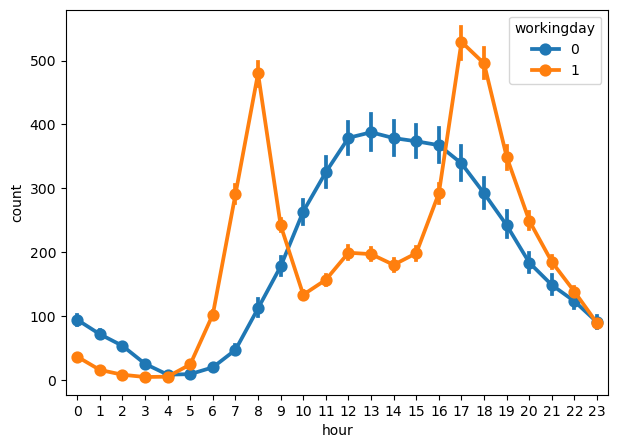

In [16]:
plt.figure(figsize=(7,5))
sns_result = sns.pointplot(data=df, x='hour', y='count', hue='workingday')

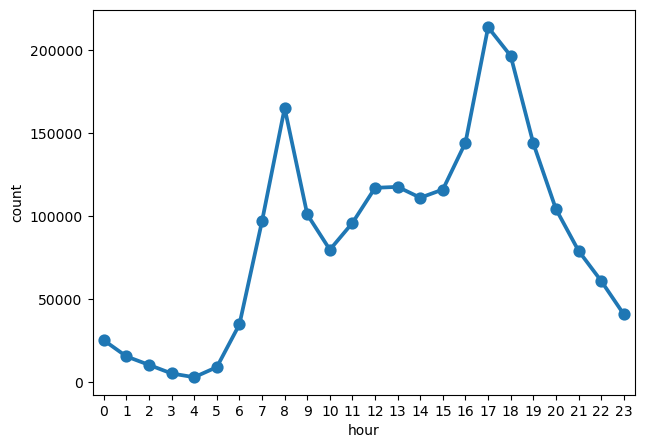

In [12]:
plt.figure(figsize=(7,5))
sns_result = sns.pointplot(data=d, x='hour', y='count')

In [13]:
d = df.groupby(['hour', 'workingday']).agg({"count":"sum"}).reset_index()
d

,hour,workingday,count
0,0,0,13701
1,0,1,11387
2,1,0,10427
3,1,1,4945
4,2,0,7686
5,2,1,2573
6,3,0,3677
7,3,1,1414
8,4,0,1239
9,4,1,1593


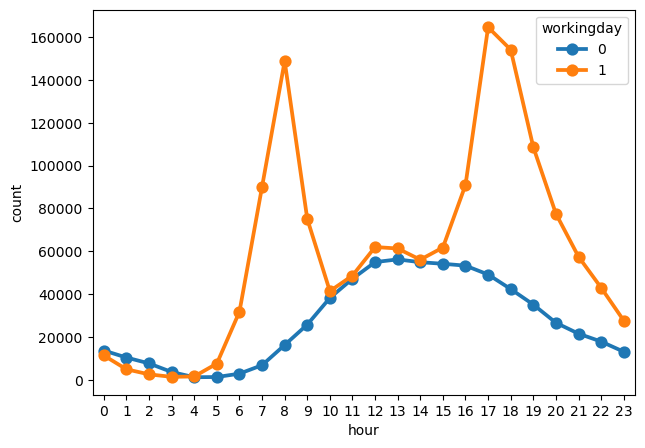

In [17]:
plt.figure(figsize=(7,5))
sns_result = sns.pointplot(data=d, x='hour', y='count', hue='workingday')

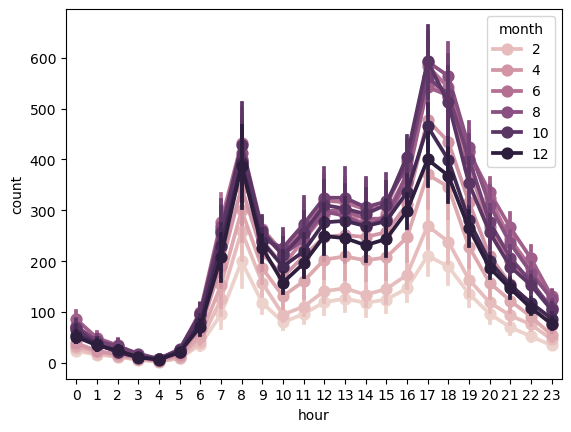

In [18]:
sns_result = sns.pointplot(data=df, x='hour', y='count', hue='month')

In [19]:
d = df.groupby(['hour', 'month']).agg({"count":"sum"}).reset_index()
d

,hour,month,count
0,0,1,852
1,0,2,1096
2,0,3,1249
3,0,4,1480
4,0,5,2441
...,...,...,...
283,23,8,4791
284,23,9,4092
285,23,10,3949
286,23,11,3310


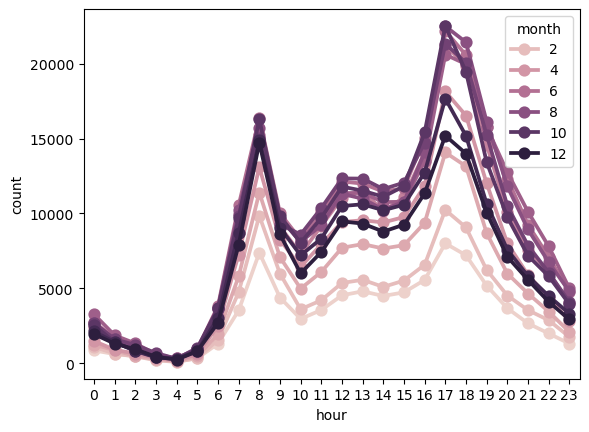

In [20]:
sns_result = sns.pointplot(data=d, x='hour', y='count', hue='month')

In [21]:
d = df.groupby(['hour', 'weather']).agg({"count":"sum"}).reset_index()
d

,hour,weather,count
0,0,1,18214
1,0,2,6106
2,0,3,768
3,1,1,10397
4,1,2,4246
...,...,...,...
68,22,2,12206
69,22,3,2567
70,23,1,29551
71,23,2,8745


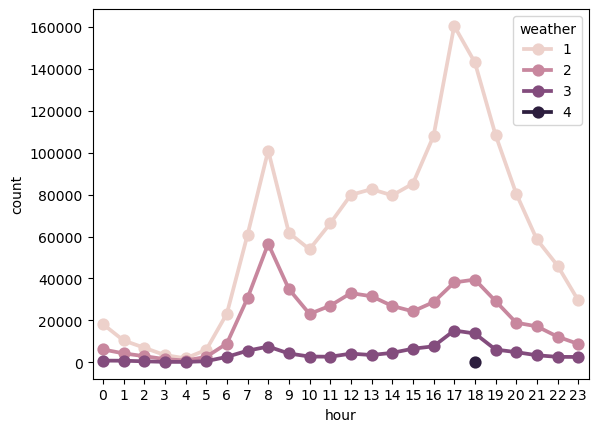

In [22]:
sns_result = sns.pointplot(data=d, x='hour', y='count', hue='weather')

In [23]:
d = df.groupby(['month']).agg({"registered":"sum","casual":"sum"}).reset_index()
d

,month,registered,casual
0,1,72632,7252
1,2,89816,9297
2,3,108445,25056
3,4,127589,39813
4,5,158862,41285
5,6,172159,48574
6,7,163670,50947
7,8,167646,45870
8,9,166628,45901
9,10,169347,38087


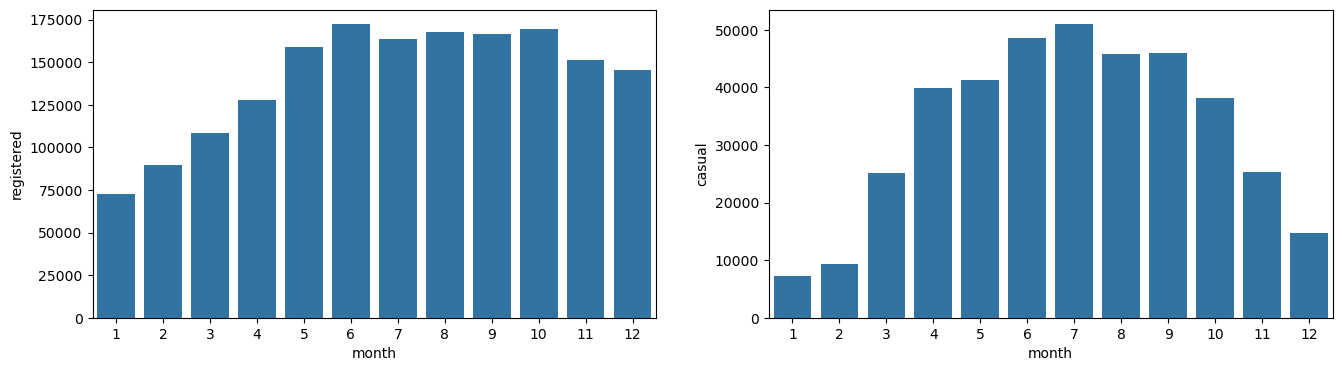

In [25]:
figure, (ax1, ax2) = plt.subplots(ncols=2)
figure.set_size_inches(16, 4)

sns.barplot(data=d, x="month", y="registered", ax=ax1)
sns.barplot(data=d, x="month", y="casual", ax=ax2)

plt.show()

In [27]:
df['temp_int'] = df['temp'].apply(int)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int64         
 15  hour        10886 non-null  int64         
 16  temp_int    10886 non-

In [29]:
d = df.groupby(['temp_int','workingday']).agg({"registered":"sum","casual":"sum","count":"sum"}).reset_index()
d

,temp_int,workingday,registered,casual,count
0,0,1,538,6,544
1,1,1,176,7,183
2,2,1,204,11,215
3,3,0,75,1,76
4,3,1,128,8,136
...,...,...,...,...,...
72,37,1,5359,1413,6772
73,38,0,658,323,981
74,38,1,516,175,691
75,39,0,1269,638,1907


C:\Users\orudw\AppData\Local\Temp\ipykernel_16836\1026173005.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1_sns.set_xticklabels(ax1_sns.get_xticklabels(), rotation=50)
C:\Users\orudw\AppData\Local\Temp\ipykernel_16836\1026173005.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2_sns.set_xticklabels(ax2_sns.get_xticklabels(), rotation=50)
C:\Users\orudw\AppData\Local\Temp\ipykernel_16836\1026173005.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3_sns.set_xticklabels(ax3_sns.get_xticklabels(), rotation=50)
C:\Users\orudw\AppData\Local\Temp\ipykernel_16836\1026173005.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4_sns.set_xtickl

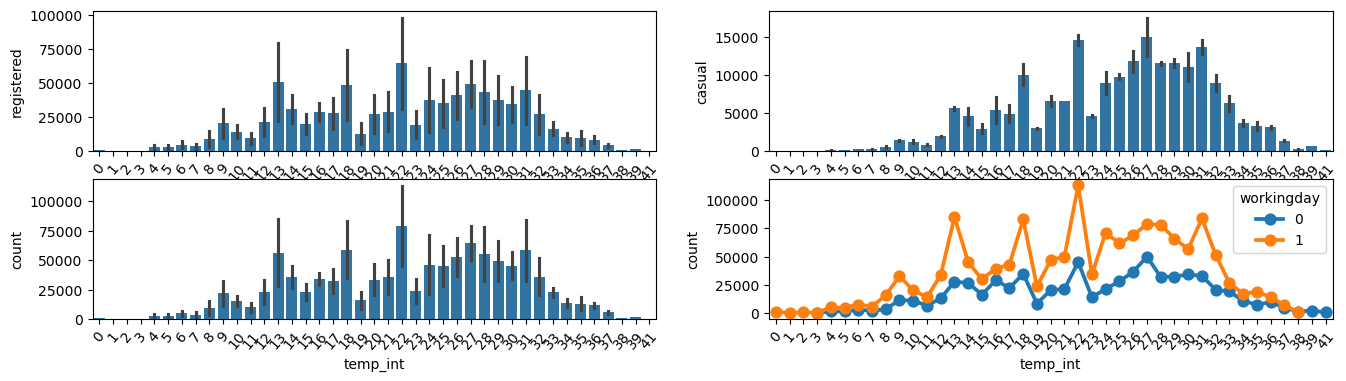

In [42]:
figure, ((ax1, ax2),(ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
figure.set_size_inches(16, 4)

ax1_sns = sns.barplot(data=d, x='temp_int', y='registered', ax=ax1)
ax1_sns.set_xticklabels(ax1_sns.get_xticklabels(), rotation=50)

ax2_sns = sns.barplot(data=d, x='temp_int', y='casual', ax=ax2)
ax2_sns.set_xticklabels(ax2_sns.get_xticklabels(), rotation=50)

ax3_sns = sns.barplot(data=d, x='temp_int', y='count', ax=ax3)
ax3_sns.set_xticklabels(ax3_sns.get_xticklabels(), rotation=50)

ax4_sns = sns.pointplot(data=d, x='temp_int', y='count', ax=ax4, hue="workingday")
ax4_sns.set_xticklabels(ax4_sns.get_xticklabels(), rotation=50)

plt.show()

### 모델링

In [41]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'year', 'month', 'day', 'hour', 'temp_int'],
      dtype='object')

In [43]:
f = ['season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
label = "count"

X, y = df[f], df[label]

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [46]:
from sklearn.ensemble import RandomForestRegressor

In [47]:
rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [49]:
pred = rfr.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

In [56]:
print("mse : ", mse)
print("rmse : ", rmse)
print("mae : ", mae)

print("정상 범주에 있다", rmse < (mae * 1.5))
print("약간 오차가 있다", (rmse >= (mae * 1.5)) & (rmse < (mae * 2)) )
print("오차가 큰게 있다", (rmse > (mae * 2)) )

print("train : ", rfr.score(X_train, y_train))
print("test : ", rfr.score(X_test, y_test))

mse :  1946.295523392529
rmse :  44.116839453801866
mae :  27.51130434782609
정상 범주에 있다 False
약간 오차가 있다 True
오차가 큰게 있다 False
train :  0.9919043555699658
test :  0.9405114437244463


In [57]:
params = {
    "n_estimators" : range(5, 100, 10), #트리 개수
    "max_depth" : range(4, 11, 2), #최대 깊이
    "min_samples_split" : range(4, 21, 4) #노드 분할 최소한의 샘플 수
}

In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
rfr = RandomForestRegressor()
grid_cv = GridSearchCV(rfr, param_grid=params, cv=3, n_jobs=-1)
grid_cv.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': range(4, 11, 2), 'min_samples_split': range(4, 21, 4), 'n_estimators': range(5, 100, 10)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,55


In [60]:
pred = grid_cv.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

In [61]:
print("mse : ", mse)
print("rmse : ", rmse)
print("mae : ", mae)

print("정상 범주에 있다", rmse < (mae * 1.5))
print("약간 오차가 있다", (rmse >= (mae * 1.5)) & (rmse < (mae * 2)) )
print("오차가 큰게 있다", (rmse > (mae * 2)) )

print("train : ", grid_cv.score(X_train, y_train))
print("test : ", grid_cv.score(X_test, y_test))

print("최적의 파라미터 : ", grid_cv.best_params_)

mse :  2430.351022357381
rmse :  49.29859047029014
mae :  31.40595139079134
정상 범주에 있다 False
약간 오차가 있다 True
오차가 큰게 있다 False
train :  0.9513058153642239
test :  0.9257162790413005
최적의 파라미터 :  {'max_depth': 10, 'min_samples_split': 8, 'n_estimators': 55}


In [62]:
df_result = pd.DataFrame({
    "y_test":[11,12,13,14,15,16,17,18,19],
    "y_pred":[10,11,12,13,14,15,16,17,18],
})

<Axes: >

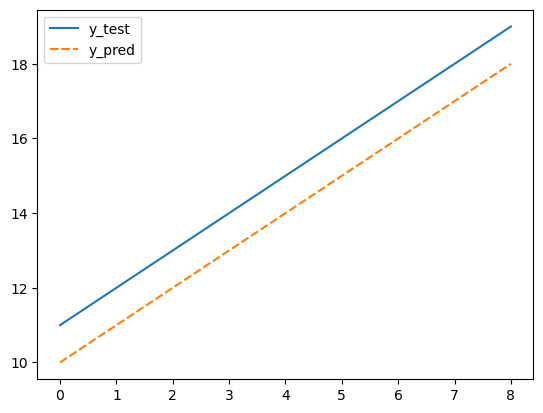

In [63]:
sns.lineplot(data=df_result)

<Axes: >

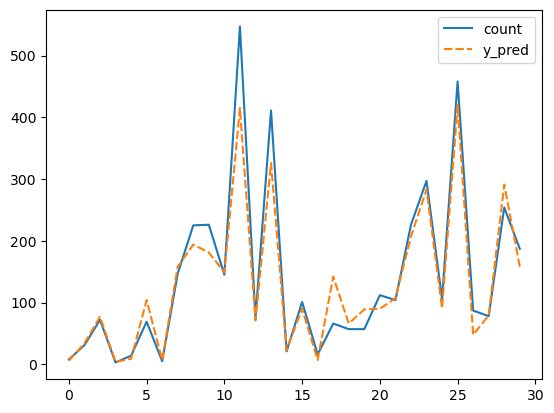

In [69]:
range_start = 0
range_end = 30
y_pred = grid_cv.predict(X_test)

y_test_reset = y_test[range_start : range_end].reset_index()
y_test_reset['y_pred'] = y_pred[range_start : range_end]
y_test_reset

y_test_reset['y_pred'] = y_test_reset['y_pred'].apply(int)
y_test_reset
sns.lineplot(data=y_test_reset[['count', 'y_pred']] )

In [65]:
len(y_test)

3266

In [70]:
df.head(1)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,temp_int
0,2011-01-01,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,9
